In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import gdown

# detect the environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# configure the paths
if IN_COLAB:
    print("Running in Google Colab. Setting up GitHub repo...")
    REPO_URL = "https://github.com/JayC-SF/COMP-432-Project.git"
    REPO_DIR = "/content/COMP-432-Project"
    
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
        
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)
        
    # change the working directory
    os.chdir(REPO_DIR)
else:
    print("Running locally. Setting up relative paths...")
    # move up only if base directory is at notebooks
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
        print(f"Working directory changed to: {os.getcwd()}")
    
    # add working dir to sys path
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())

Running locally. Setting up relative paths...
Working directory changed to: /home/jcsf/school/4.winter2026/COMP432/project/COMP-432-Project


## 1. CNN Pipelines
We first 

In [2]:
# necessary imports for the CNN Pipelines
from src.preprocess_data import download_and_extract, convert_audio_dataset_to_mel
import src.variables as v

In [3]:

download_and_extract(v.AUDIO_ZIP_FILE_PATH, v.AUDIO_ZIP_GID, v.AUDIO_DATA_PATH)
download_and_extract(v.METADATA_ZIP_FILE_PATH, v.METADATA_ZIP_GID, v.METADATA_PATH)

data/audio already exists.
data/metadata already exists.


In [4]:
convert_audio_dataset_to_mel(v.AUDIO_DATA_PATH, v.MEL_SPECTOGRAM_PATH)

data/mel_spectogram already exists, skipping convertion...


In [10]:
import numpy as np
import glob
import os

shapes = set()
file_list = sorted(glob.glob(os.path.join(base_path, "**/*.npy"), recursive=True))
for i, file_path in enumerate(file_list):
    f = np.load(file_path).astype(np.float32)
    shapes.add(f.shape)

shapes

{(128, 38),
 (128, 71),
 (128, 86),
 (128, 100),
 (128, 106),
 (128, 116),
 (128, 126),
 (128, 146),
 (128, 152),
 (128, 161),
 (128, 167),
 (128, 170),
 (128, 178),
 (128, 184),
 (128, 191),
 (128, 192),
 (128, 193),
 (128, 198),
 (128, 200),
 (128, 202),
 (128, 204),
 (128, 205),
 (128, 206),
 (128, 207),
 (128, 208),
 (128, 210),
 (128, 213),
 (128, 215),
 (128, 218),
 (128, 225),
 (128, 227),
 (128, 229),
 (128, 235),
 (128, 237),
 (128, 238),
 (128, 245),
 (128, 252),
 (128, 253),
 (128, 256),
 (128, 260),
 (128, 261),
 (128, 264),
 (128, 265),
 (128, 266),
 (128, 268),
 (128, 270),
 (128, 274),
 (128, 276),
 (128, 277),
 (128, 279),
 (128, 280),
 (128, 281),
 (128, 282),
 (128, 283),
 (128, 284),
 (128, 285),
 (128, 286),
 (128, 287),
 (128, 288),
 (128, 289),
 (128, 290),
 (128, 291),
 (128, 292),
 (128, 293),
 (128, 294),
 (128, 295),
 (128, 296),
 (128, 297),
 (128, 298),
 (128, 299),
 (128, 300),
 (128, 301),
 (128, 302),
 (128, 303),
 (128, 304),
 (128, 305),
 (128, 306),
 (

In [12]:
shapes = {}
for i, file_path in enumerate(file_list):
    f = np.load(file_path).astype(np.float32)
    shapes[f.shape[1]] = file_path
shapes

{313: 'data/mel_spectogram/validation/strong_val/synth_trainval_Snoring_999.npy',
 308: 'data/mel_spectogram/validation/strong_val/strong_Infantcry_39.npy',
 306: 'data/mel_spectogram/validation/strong_val/strong_Infantcry_99.npy',
 291: 'data/mel_spectogram/train/weak/weak_Snoring_200.npy',
 284: 'data/mel_spectogram/validation/strong_val/strong_Infantcry_321.npy',
 298: 'data/mel_spectogram/train/weak/weak_Snoring_1251.npy',
 289: 'data/mel_spectogram/train/weak/weak_Infantcry_934.npy',
 282: 'data/mel_spectogram/validation/strong_val/strong_Infantcry_323.npy',
 311: 'data/mel_spectogram/validation/strong_val/strong_Infantcry_24.npy',
 309: 'data/mel_spectogram/train/weak/weak_Snoring_1525.npy',
 302: 'data/mel_spectogram/train/weak/weak_Infantcry_921.npy',
 299: 'data/mel_spectogram/validation/strong_val/strong_Infantcry_297.npy',
 304: 'data/mel_spectogram/train/weak/weak_Infantcry_604.npy',
 283: 'data/mel_spectogram/train/weak/weak_Infantcry_984.npy',
 256: 'data/mel_spectogram/t

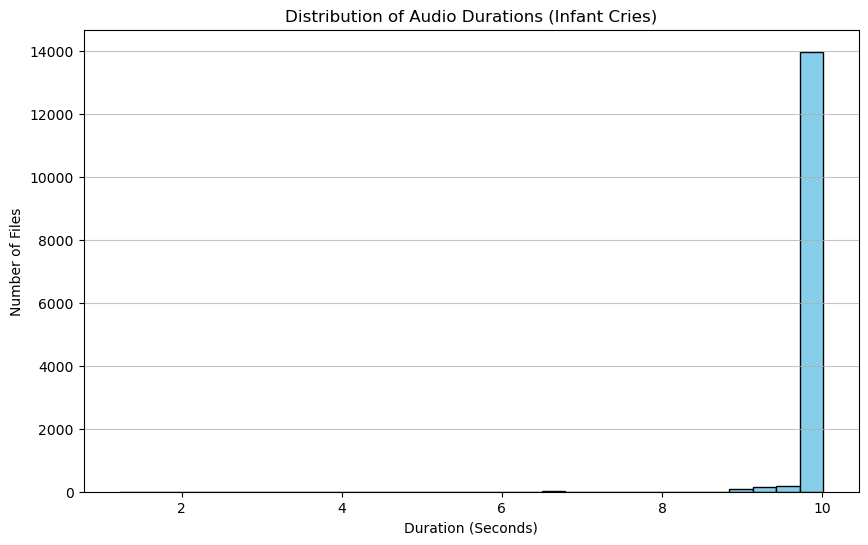

Shortest: 1.22s
Longest: 10.02s
Median: 10.02s
[10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 9.856, 9.792, 10.016, 9.312, 9.088, 10.016, 10.016, 10.016, 9.792, 10.016, 10.016, 10.016, 9.536, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 9.248, 10.016, 9.024, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 10.016, 

In [ ]:
import matplotlib.pyplot as plt
# We use mmap_mode='r' to just "peek" at the header/shape without loading data
lengths = [np.load(f, mmap_mode='r').shape[1] for f in file_list]

# Convert "pixels" to "seconds" for better readability
# (Width * Hop_Length) / Sample_Rate
seconds = [(w * 512) / 16000 for w in lengths]

plt.figure(figsize=(10, 6))
plt.hist(seconds, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Audio Durations (Infant Cries)')
plt.xlabel('Duration (Seconds)')
plt.ylabel('Number of Files')
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Shortest: {min(seconds):.2f}s")
print(f"Longest: {max(seconds):.2f}s")
print(f"Median: {np.median(seconds):.2f}s")

In [ ]:
times = {}
for s in seconds:
    times[s] = times.get(s, 0)+1
times

{10.016: 13827,
 9.856: 22,
 9.792: 18,
 9.312: 10,
 9.088: 16,
 9.536: 27,
 9.248: 16,
 9.024: 14,
 9.952: 15,
 9.888: 20,
 9.664: 22,
 9.568: 17,
 9.728: 20,
 9.056: 23,
 8.192: 1,
 9.344: 12,
 9.632: 22,
 9.184: 21,
 9.984: 16,
 9.92: 11,
 9.12: 25,
 9.696: 23,
 9.152: 17,
 3.712: 2,
 9.44: 22,
 9.216: 14,
 9.472: 17,
 9.376: 17,
 8.992: 9,
 7.616: 2,
 9.408: 19,
 6.56: 4,
 8.768: 1,
 8.64: 2,
 9.6: 15,
 9.76: 13,
 9.824: 20,
 4.032: 2,
 9.28: 12,
 6.72: 3,
 2.752: 1,
 8.064: 1,
 8.32: 1,
 5.152: 1,
 6.144: 1,
 3.2: 1,
 7.84: 1,
 9.504: 12,
 7.328: 2,
 8.48: 1,
 6.336: 1,
 6.656: 1,
 6.88: 1,
 6.976: 2,
 8.832: 2,
 8.96: 1,
 6.464: 1,
 6.816: 1,
 2.272: 1,
 8.096: 1,
 6.176: 1,
 7.52: 1,
 6.624: 1,
 5.696: 1,
 8.352: 1,
 7.2: 1,
 6.528: 2,
 6.4: 1,
 7.264: 1,
 4.864: 1,
 8.576: 1,
 4.672: 1,
 8.512: 1,
 7.584: 1,
 3.392: 1,
 1.216: 1,
 5.888: 1,
 5.44: 1,
 6.112: 1,
 6.592: 1,
 8.864: 1,
 8.448: 1,
 8.928: 1,
 5.344: 1}

10.016

In [ ]:
import numpy as np
import glob
import os

# 1. Gather all file paths
base_path = str(v.MEL_SPECTOGRAM_PATH)
file_list = sorted(glob.glob(os.path.join(base_path, "**/*.npy"), recursive=True))
# 2. Peak at the first file to get the shape
sample_shape = np.load(file_list[0]).shape
print(sample_shape)
target_width =  

# 3. Pre-allocate the memory (This is the most RAM-efficient way)
# Total size will be (Number of Files, 128, TimeSteps)
X_train = np.zeros((len(file_list), *sample_shape), dtype=np.float32)

print(f"Allocating {X_train.nbytes / 1e9:.2f} GB of RAM...")

# 4. Fill the array
for i, file_path in enumerate(file_list):
    # Cast to float32 immediately to save space
    X_train[i] = np.load(file_path).astype(np.float32)

print("All data loaded successfully!")

(128, 313)
Allocating 2.32 GB of RAM...


ValueError: could not broadcast input array from shape (128,308) into shape (128,313)

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert your big NumPy arrays to PyTorch Tensors
# We do this once. It stays in RAM.
X_tensor = torch.from_numpy(X_train).float()
y_tensor = torch.from_numpy(y_train).long()

# 2. Create a Dataset object (doesn't take extra RAM, just points to the tensors)
dataset = TensorDataset(X_tensor, y_tensor)

# 3. The DataLoader handles shuffling and batching
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Now your training loop is clean:
# for batch_idx, (data, target) in enumerate(train_loader):
#     ... train your model ...